# (14) vH16 — STA

**Motivation**: host = ```any```, device = ```cuda:3``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.chosen import *
from figures.analysis import *
from figures.imgs import plot_weights

device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Load

MLP, whitened

In [3]:
tr, meta = load_model(
    'poisson_vH16_t-16_z-[512]_<jacob|lin>',
    'b200-ep300-lr(0.002)_beta(6:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2024_10_12,06:53)',
    device=device,
)
meta['checkpoint']

300

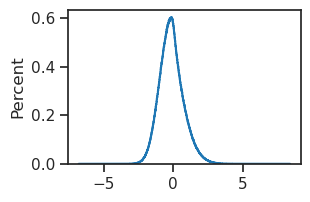

In [4]:
_ = histplot(tr.dl_vld.dataset.tensors[0].ravel(), stat='percent')

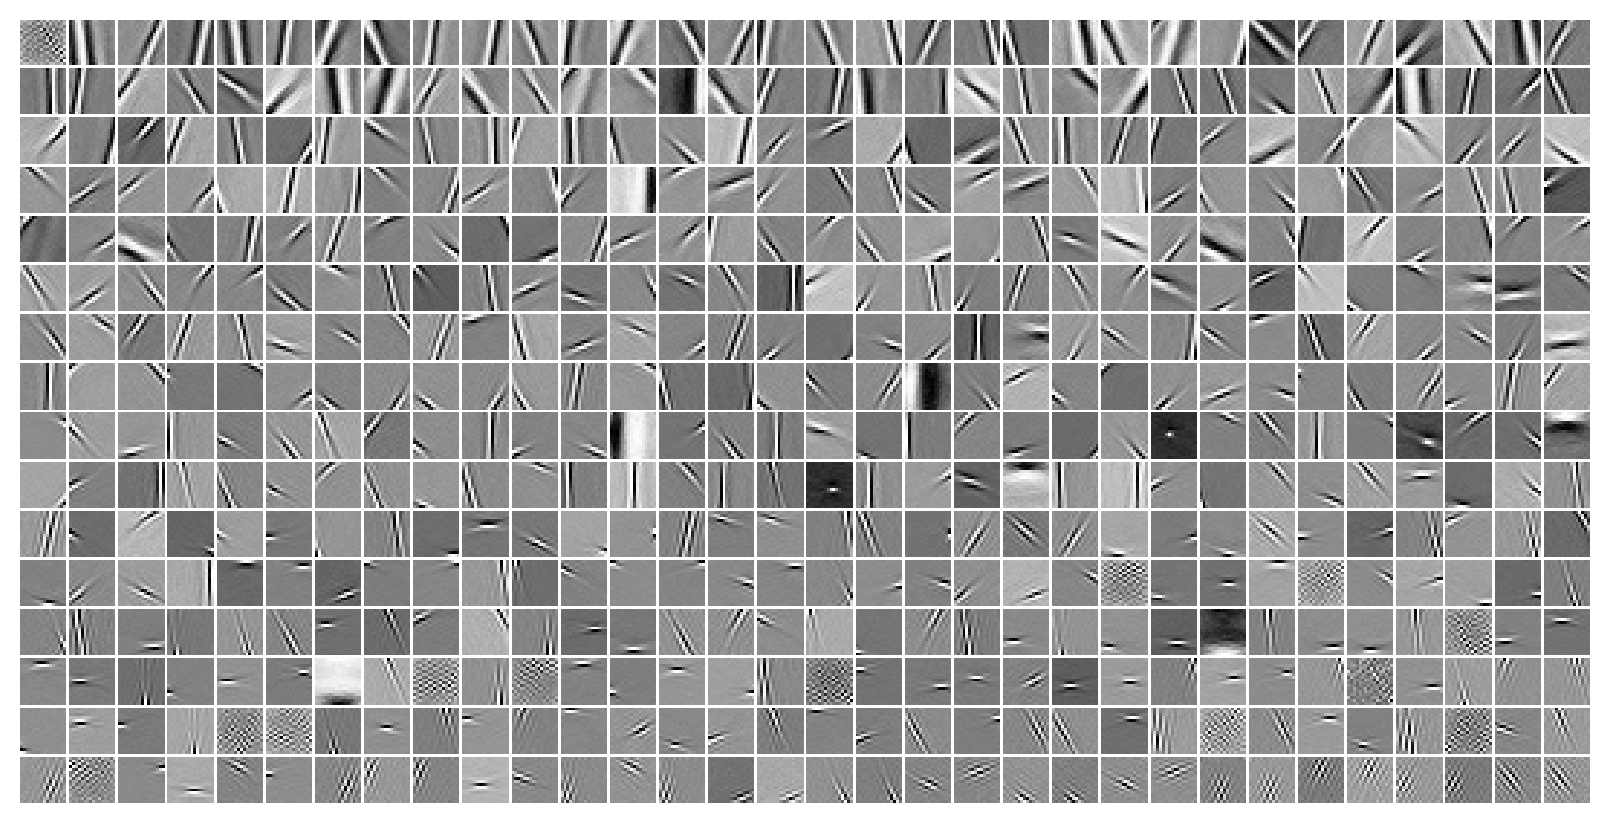

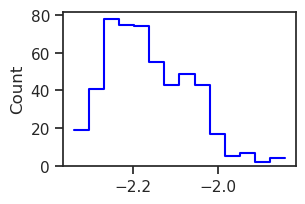

In [5]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))

_ = tr.model.show(order=np.argsort(norms))

histplot(np.log(norms), label='log norm', color='b');

### Generate noise stimlui

In [6]:
x_trn = tr.dl_trn.dataset.tensors[0]
std = torch.std(x_trn)
noise = torch.randn_like(x_trn) * std
noise.shape

torch.Size([103145, 1, 16, 16])

In [7]:
std

tensor(0.8639, device='cuda:3')

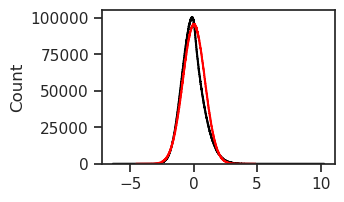

In [8]:
histplot(x_trn.ravel(), color='k')
histplot(noise.ravel(), color='r')
plt.show()

### Make noise dataset

In [9]:
noise = torch.utils.data.dataset.TensorDataset(noise)

### Run inference

100%|███████████████████████████████| 516/516 [19:08<00:00,  2.23s/it]


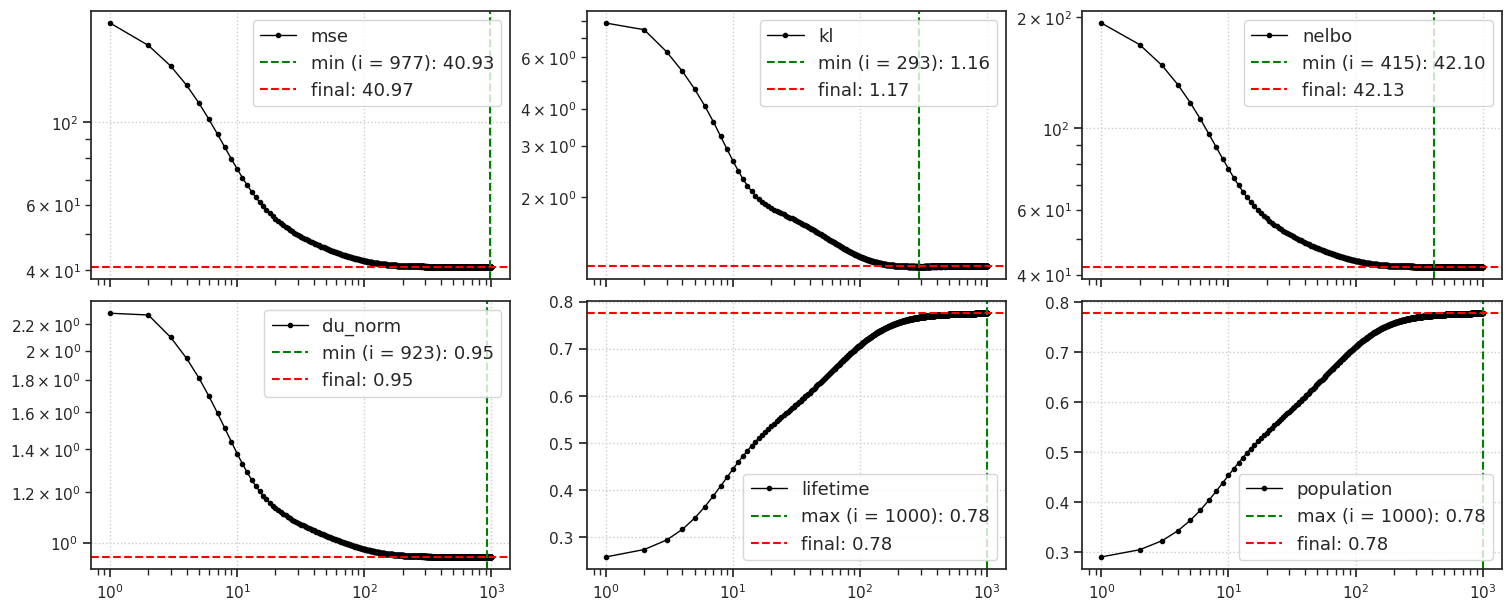

CPU times: user 24min 39s, sys: 2min 55s, total: 27min 34s
Wall time: 27min 33s


In [35]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=None,
)
results = tr.analysis(noise, **kws)

_ = plot_convergence(results, color='k')

In [36]:
list(results)

['kl',
 'mse',
 'nelbo',
 'du_norm',
 'lifetime',
 'population',
 'state_final',
 'samples_final']

In [37]:
spks = results['state_final']
spks.shape

(103145, 512)

In [38]:
sta = compute_sta(
    n_lags=10,
    stim=noise.tensors[0][:len(spks)],
    spks=tr.to(spks),
    verbose=True,
)

100%|███████████████████████████████████| 103134/103134 [23:47<00:00, 72.22it/s]


In [39]:
sta.shape

torch.Size([512, 11, 1, 16, 16])

In [50]:
time = -1
x2p = tonp(sta[:, time, ...].squeeze())
x2p.shape

(512, 16, 16)

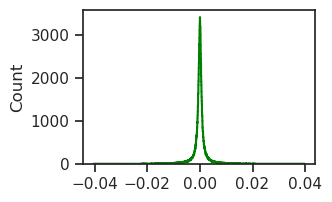

In [58]:
histplot(x2p.ravel(), color='g');

In [59]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))
order = np.argsort(norms)

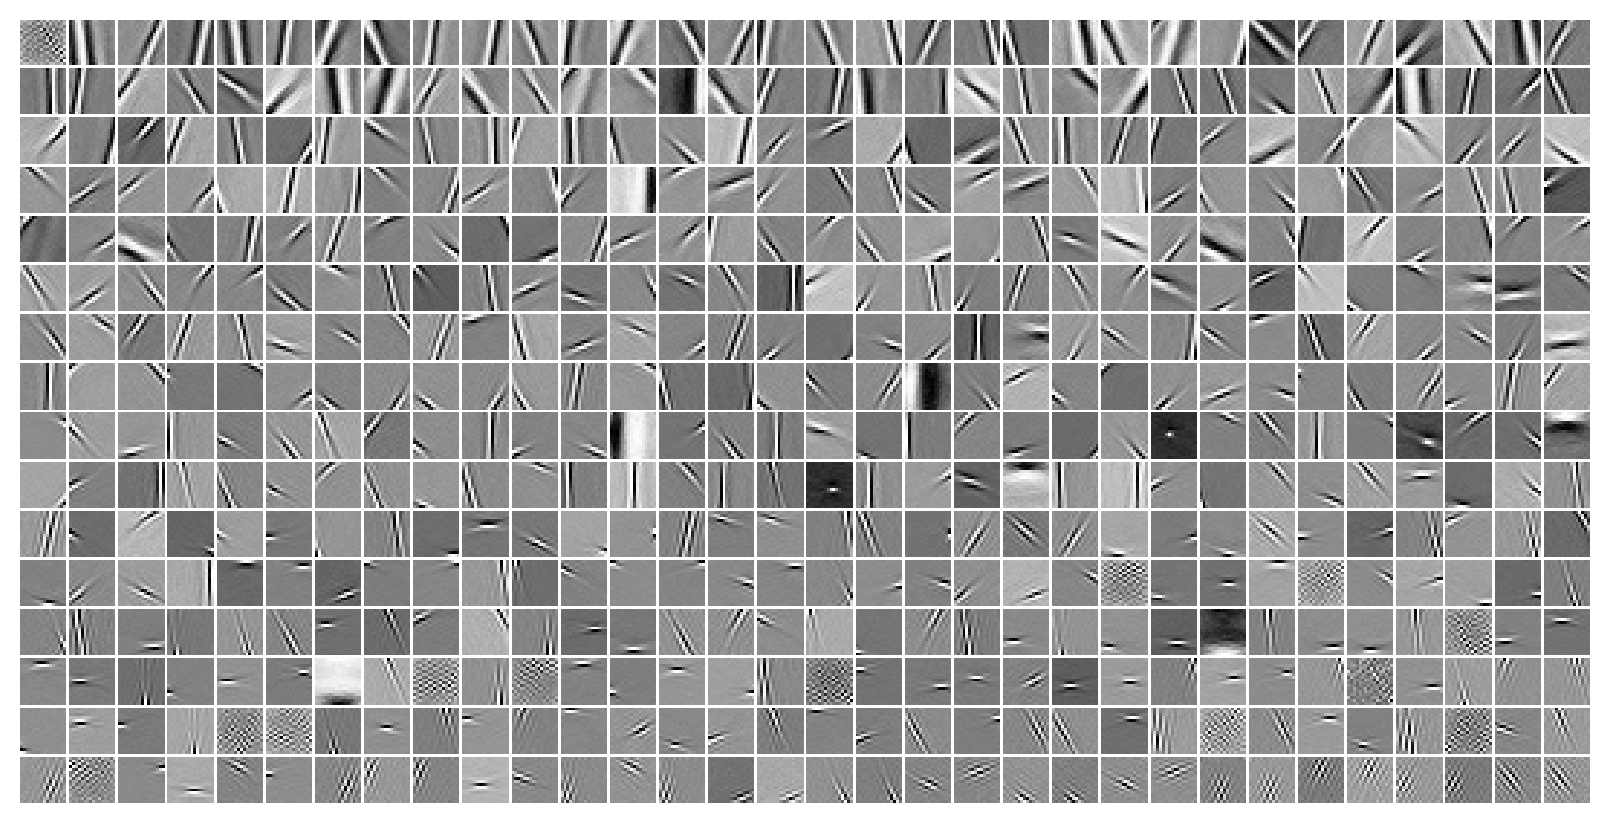

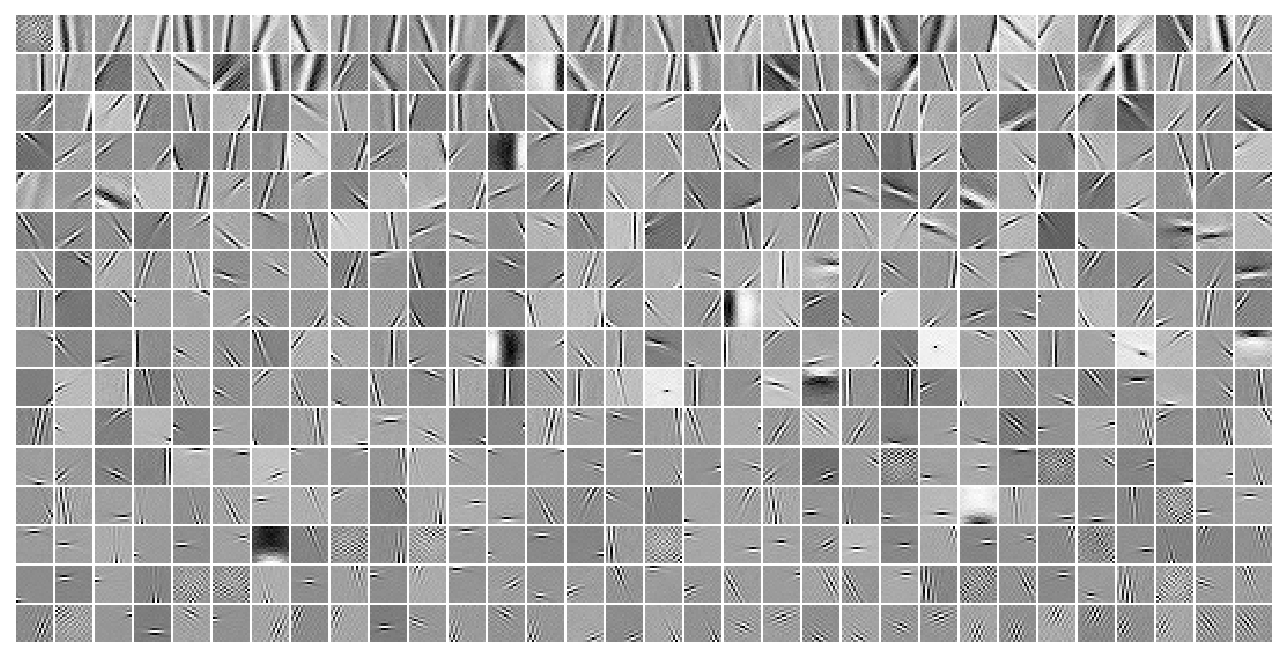

In [60]:
_ = tr.model.show(order=order)
_ = plot_weights(x2p[order])